### Medical Insurance Cost Analysis


### Task 1 — Business Understanding

**Target Variable:** `charges`

**Input Risk Factors:** age, sex, bmi, children, smoker, region

Multiple Linear Regression helps identify **which factors increase insurance costs**, allowing the company to design **risk-based premium plans** instead of only predicting costs.

In [1]:

target = 'charges'
features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
target, features


('charges', ['age', 'sex', 'bmi', 'children', 'smoker', 'region'])

### Task 2 — Data Inspection

In [2]:

import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

numeric_cols, categorical_cols


(Index(['age', 'bmi', 'children', 'charges'], dtype='object'),
 Index(['sex', 'smoker', 'region'], dtype='object'))

In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Task 3 — Data Cleaning & Encoding

In [6]:

df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})


In [7]:

df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### Task 4 — Feature Scaling & Comparability

In [8]:

X = df.drop('charges', axis=1)
y = df['charges']
X.describe()


,age,sex,bmi,children,smoker
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783
std,14.049960,0.500160,6.098187,1.205493,0.403694
min,18.000000,0.000000,15.960000,0.000000,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000


In [9]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Task 5 — Multicollinearity Analysis

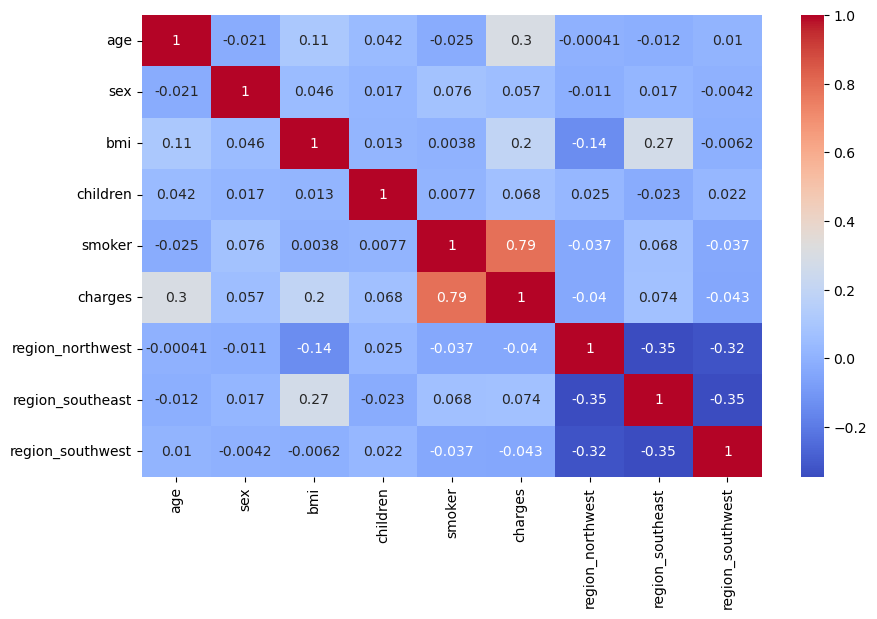

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [11]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i)
                   for i in range(X_scaled.shape[1])]

vif_data


,Feature,VIF
0,age,1.016822
1,sex,1.008900
2,bmi,1.106630
3,children,1.004011
4,smoker,1.012074
5,region_northwest,1.518823
6,region_southeast,1.652230
7,region_southwest,1.529411


### Multiple Linear Regression Model

In [12]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [13]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients


,Feature,Coefficient
4,smoker,9544.251089
0,age,3609.149018
2,bmi,2054.885063
3,children,512.478869
1,sex,-9.295337
5,region_northwest,-158.959435
6,region_southeast,-292.759080
7,region_southwest,-347.270359


### Model Evaluation

In [15]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(4181.194473753653, np.float64(5796.284659276274), 0.7835929767120722)

### Actual vs Predicted Charges

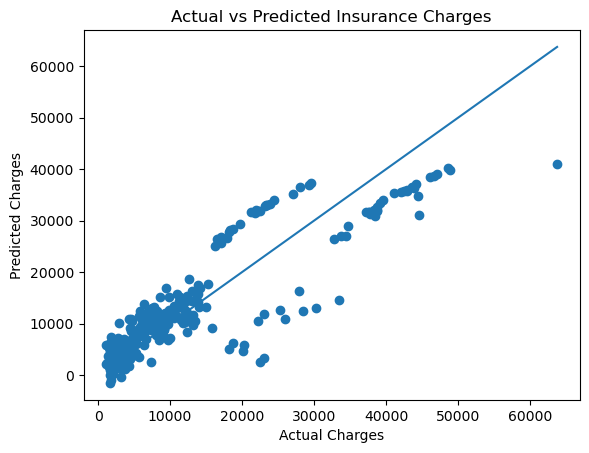

In [16]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()


### Optional — Ridge Regression (Multicollinearity Fix)

In [17]:

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge.score(X_test, y_test)


0.7835411843918458

### Conclusion

- **Smoker** is the strongest cost driver
- **BMI & Age** have moderate impact
- Regression supports **fair & risk-based pricing**